# Project Chrono 
- 작성자: dh
- 작성일: 3/24 <캡스톤 4주차>

====================================================================

# [0] Pychrono 개요

Project Chrono
→ 다물체 동역학 + 충돌 + FEA까지 가능한 물리엔진

PyChrono = Python wrapper
→ Python에서 바로 시뮬레이션 가능

핵심 기능:

- rigid body dynamics
- contact & friction
- joints / constraints
- vehicle / robotics / FEA

#### 이 문서에서는 크로노의 NSC 환경과, 크로노 내부엔진의 장동 방식을 정리합니다.
(요약)
1. 크로노에서 NSC 환경 설정하는 방법
2. 이론값과 시뮬레이션값
3. 크로노 내부엔진 로직 분석


====================================================================

# [1] Chrono에서 NSC 환경 설정하기

## 0. 라이브러리 import
: Chrono 물리엔진을 Python에서 사용하기 위한 모듈 로드

- 내부적으로는 C++ 엔진을 Python에서 호출하는 구조
- 이후 모든 객체는 chrono. 네임스페이스에서 생성

## 1. 시스템 생성
: 전체 물리 세계 생성

의미:
- 하나의 “시뮬레이션 공간”
- 모든 물체, 힘, 충돌, 제약조건이 여기에 포함됨

#### NSC란?
-> Non-Smooth Contact
- 비연속(non-smooth) 접촉 모델로 접촉 순간에 속도/힘이 불연속적으로 변하는 것을 허용
- 물리적 의미: 공이 바닥에 떨어질 때 속도가 갑자기 바뀌고, 힘이 순간적으로 매우  커지는것을 그대로 모델링

- 즉, 충돌을 “충격 기반(impulse)”으로 처리
→ 빠르고 안정적 (차량/로봇에 많이 사용)

수식 형태:
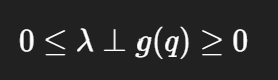
- 𝑔(𝑞): 접촉 거리 (gap)
- 𝜆: 접촉력
- 예시:

- 접촉 안함 → 힘 없음 : 𝑔(𝑞) > 0 → 𝜆 = 0 
- 힘 있음 → 접촉 함 :  𝜆 > 0 → f(x) = 0

-complementarity condition

| 조건                | 의미               |
| ----------------- | ---------------- |
| ( g(q) > 0 )      | 떨어져 있음 → 힘 없음    |
| ( g(q) = 0 )      | 접촉               |
| ( 𝜆 >= 0 ) | 밀기만 가능 (당길 수 없음) |


## 2. 중력 설정
: 시스템 전체에 작용하는 중력

- 의미:
모든 물체에 자동으로 적용됨
y축 방향으로 -9.81 m/s²

## 3. 재질 설정
: 접촉 시 물리적 성질 정의

- 의미:
마찰계수 = 0.3
나중에 충돌할 때 사용됨

 - 현재 코드에서는:
 충돌 shape를 안 넣었기 때문에 실제로는 영향 없음


In [17]:
import pychrono as chrono

# 1. 시스템 생성
sys = chrono.ChSystemNSC()
# ChSystemNSC = Non-Smooth Contact 방식의 물리 시스템

# 2. 중력 설정
sys.SetGravitationalAcceleration(
    chrono.ChVector3d(0, -9.81, 0)
)

# 재질
material = chrono.ChContactMaterialNSC()
material.SetFriction(0.3)


## 4. Body 설정
1) Body A (고정물체) 
물리적 의미: 무한 질량처럼 동작 -> ground 역할
- m=20kg,
- 관성모멘트=(10,10,10)
- 초기위치=(1,-1,0)

2) Body B (움직이는물체)
물리적 의미: 무한 진량처럼 동작
- m=1kg
- 관성모멘트=기본값
- 초기위치 = (0,2,0)

In [ ]:
# Body A (ground)
bodyA = chrono.ChBody()
bodyA.SetMass(20) # 질량 = 20kg
bodyA.SetName('BodyA')
bodyA.SetInertiaXX(chrono.ChVector3d(10,10,10)) # 관성 텐서: 회전에 대한 z,y,z 방향 관성에의한 저항
bodyA.SetPos(chrono.ChVector3d(1,-1,0)) # 초기 위치 설정 (X,Y,Z)=(-1,-1,0)
bodyA.SetFixed(True) # 고정 설

my_system.Add(bodyA) # 시스템에 추가 -> 시스템에 등록해야 시뮬레이션에 포함됨

# Body B
bodyB = chrono.ChBody()
bodyB.SetName('BodyB')
bodyB.SetPos(chrono.ChVector3d(0,2,0)) # 초기 위치 설정 (X,Y,Z)=(0,2,0)

my_system.Add(bodyB)

## 5. 시뮬레이션 루프
- time step=0.01s
- 시뮬레이션 시간=1s

my_system.DoStepDynamics(dt)
물리엔진이 실제 계산 수행
-> 내부에서 일어나는 일:
- 힘 계산 (중력 등)
- 운동방정식 풀기 (F = ma)
- 속도 업데이트
- 위치 업데이트
- 충돌 검사 (있다면)

In [ ]:
# 시뮬레이션
time = 0
dt = 0.01

while time < 1:
    my_system.DoStepDynamics(dt) ## 물리엔진 계산 수행
    print("time:", time, " y:", bodyB.GetPos().y)
    time += dt

time: 0  y: 1.99902
time: 0.01  y: 1.99706
time: 0.02  y: 1.9941200000000001
time: 0.03  y: 1.9902000000000002
time: 0.04  y: 1.9853000000000003
time: 0.05  y: 1.9794200000000002
time: 0.060000000000000005  y: 1.97256
time: 0.07  y: 1.96472
time: 0.08  y: 1.9559
time: 0.09  y: 1.9461
time: 0.09999999999999999  y: 1.93532
time: 0.10999999999999999  y: 1.92356
time: 0.11999999999999998  y: 1.91082
time: 0.12999999999999998  y: 1.8971
time: 0.13999999999999999  y: 1.8824
time: 0.15  y: 1.8667200000000002
time: 0.16  y: 1.8500600000000003
time: 0.17  y: 1.8324200000000002
time: 0.18000000000000002  y: 1.8138
time: 0.19000000000000003  y: 1.7942
time: 0.20000000000000004  y: 1.77362
time: 0.21000000000000005  y: 1.75206
time: 0.22000000000000006  y: 1.72952
time: 0.23000000000000007  y: 1.706
time: 0.24000000000000007  y: 1.6815
time: 0.25000000000000006  y: 1.65602
time: 0.26000000000000006  y: 1.6295600000000001
time: 0.2700000000000001  y: 1.6021200000000002
time: 0.2800000000000001  y: 

===========================================================================

# [2] 이론값 vs 시뮬레이션(chrono)

## 1. 이론해 구하기
예: 자유낙하
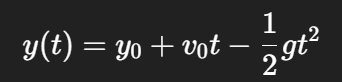

- 미분방정식을 직접 풀어서 얻은 결과

--------------------------------------------------------------------------

## 2. 시뮬레이션의 물리엔진 내부 로직 : 수치해석

#### DoStepDynamics(dt) 로 호출되는 함수의 내부 로직을 분석합니다. 

##### 1) 외력 계산
- 각 body에 작용하는 힘 계산 
- 예: 중력, 스프링, 외력
- 자유낙하: F=m*g

##### 2) 운동방정식 구성
- 각 body에 대해: Ma=F 행렬식 구성

##### 3) 제약조건 처리(있으면)
- 예: 조인트, 충돌

##### 4) solver 실행 ***
- 선형/비선형 시스템 계산 (힘+충돌+제약 동시에 만족시키는 해 계산)
- Mixed Complementarity Problem (MPC) 기준

#### (참고) MCP에 관하여 :Mixed Complementarity Problem
MCP 는 물체가 겹치지 않으면서도 물리 법칙을 만족하도록 만드는 수학적 장치
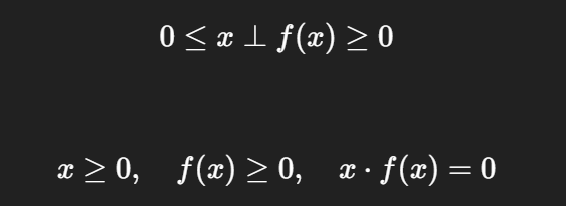
- 즉, x, f(x)중 둘중 하나만 활성화 된다. 
- x > 0 → f(x) = 0
- f(x) > 0 → x = 0

##### 5) 시간 적분 - 수치적분 수행(numerical integration)
- 한 스텝에서 예시:
- a = F/m
- v(t+dt) = v(t) + a * dt
- x(t+dt) = x(t) + v * dt




--------------------------------------------------------------------------

## 3. 이론해와 차이나는 이유 분석
### 이유1) 시간 이산화 (discretization)
- 이론: 연속시간
- chrono: dt(0.01초)만큼 끊어서 계산

### 이유2) 적분 방법
chorono가 사용하는 수치 적분 방법
##### 방법 1. semi-implicit Euler
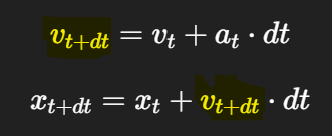
- 에너지 안정성 좋음
- 진동계에서 훨씬 안정
- 구현 간단

##### 방법 2. implicit integrator ***
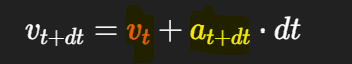
- 미래 값을 사용해서 계산
- a_t+dt는 아직 모름 -> 미래 상태까지 포함한 방정식을 solver로 풀어버리며 해결
- 안정성 매우 높음
- 속도 느림
- 정확도 높음

##### 방법 3. (참고) Explicit Euler : chrono에서는 거의 안씀
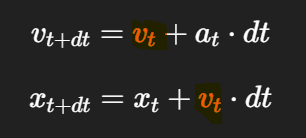
- 계산빠름
- 불안정 (특히 진동계)

### 이유3) 오차 누적
작은 오차가 계속 누적된다. 

===================================================================

# [3] (심화) Chrono 내부엔진 작동방식

## 3-1. NSC (Non-Smooth Contact)의 경우
- 기본 운동방정식:
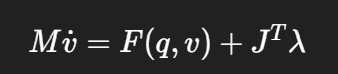

- 제약조건&접촉:
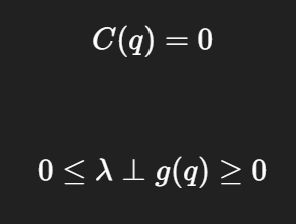

## 3-1 예시: Implicit 방식

### step1. 외력 계산 (F)

### step2. tltmxpa godfuf rntjd (M,J)
### step3. 시간 이산화 
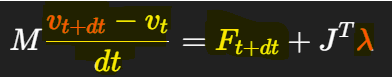
정리하면,
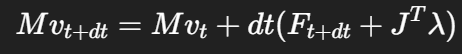
v_t+dt, λ 둘 다 모름

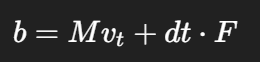

### step4. MCP 문제 생성
- Ax=b 또는 Mixed Complementarity Problem (MCP) 로 변환
- x = [velocity, constraint force]
- A = 질량 + 제약 행렬
- b = 외력 + 이전 상태

NSC일때: 
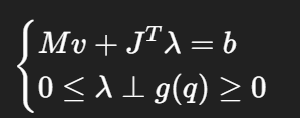
| 변수        | 의미                  |
| --------- | ------------------- |
| (v)       | 속도                  |
| (𝜆) | 접촉력   |
| (M)       | 질량 행렬               |
| (J)       | constraint Jacobian |


### step5. iterative solver 실행
방법:
- Projected Gauss-Seidel (PGS)
- Barzilai-Borwein
- MINRES

#### PGS방법 예시
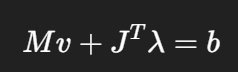
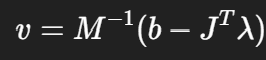
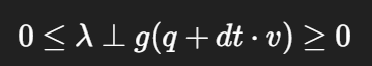


### iterative 방식

초기 λ = 0

for iter:
    for 각 접촉 i:
        λ_i 업데이트
        λ_i = max(0, λ_i_new)  ← projection

In [22]:
import numpy as np

# 시스템 파라미터
m = 1.0
g = -10
dt = 0.1

# 초기 상태
v = -1.0
y = -0.1  # penetration 상태

# 외력
F = m * g

# b 계산
b = m * v + dt * F

# Jacobian (y 방향)
J = np.array([[1.0]])  # 1D

# 초기 λ
lam = 0.0

# PGS 반복
for _ in range(10):
    # v 계산
    v_new = (b - J.T * lam) / m

    # 위치 예측
    y_new = y + dt * v_new

    # constraint violation
    gap = y_new

    # λ 업데이트
    lam = lam - gap * 10   # relaxation

    # projection
    lam = max(0, lam)

# 최종 결과
v_final = (b - J.T * lam) / m
y_final = y + dt * v_final

print("lambda:", lam)
print("v:", v_final)
print("y:", y_final)

lambda: [[3069.]]
v: [[-3071.]]
y: [[-307.2]]
